# 02 - Exploratory Data Analysis

Explore distributions, relationships, trends, and category frequencies in the ticket data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

df=pd.read_csv('D:\\customer_support-ai\\data\\customer_support_tickets.csv')
df.head()

,Ticket ID,Customer Name,Customer Email,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Priority,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,TKT-1001,Arjun Sharma,invalid_email,Wireless Mouse,03-12-2025,Product Question,Refund request,Need information about warranty,Low,8.3,214.3,1
1,TKT-1002,Isha Krishnan,isha.krishnan5@gmail.com,laptop pro 15,01-08-2025,Product Question,Compatibility issue,Bluetooth connection drops frequently.,Low,7.0,172.4,5
2,TKT-1003,Devansh Joshi,invalid_email,gaming console z,03-09-2025,Product Question,Warranty inquiry,unacceptable delay! Need information about wa...,High,5.1,192.4,3
3,TKT-1004,Devansh Sharma,devansh.sharma3@gmail.com,wireless mouse,03-07-2025,Cancellation Request,Product setup,Delivery arrived much later than expected.,Low,18.8,103.8,5
4,TKT-1005,Ananya Patel,invalid_email,smartwatch v2,02-01-2025,Cancellation Request,Delivery delay,Not compatible with my device.,Low,18.8,131.0,4


In [2]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Product Purchased',
       'Date of Purchase', 'Ticket Type', 'Ticket Subject',
       'Ticket Description', 'Ticket Priority', 'First Response Time',
       'Time to Resolution', 'Customer Satisfaction Rating'],
      dtype='object')

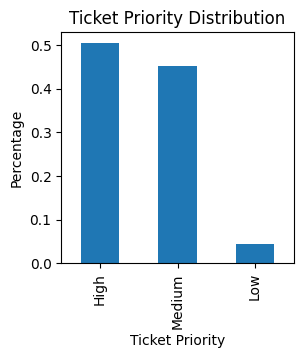

In [3]:
df["Ticket Priority"].value_counts(normalize=True).plot(
    kind="bar",
    figsize=(3, 3)
)

plt.xlabel("Ticket Priority")
plt.ylabel("Percentage")
plt.title("Ticket Priority Distribution")

plt.show()

<Axes: title={'center': 'Ticket type distribution'}, xlabel='Ticket Type', ylabel='ticket count range'>

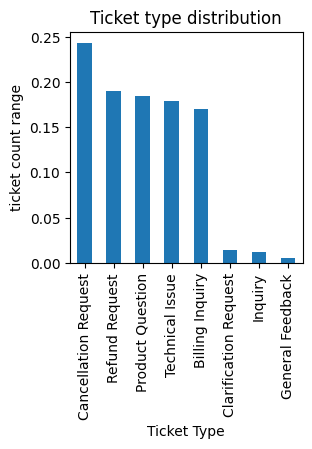

In [4]:
df["Ticket Type"].value_counts(normalize=True).plot(kind='bar',figsize=(3, 3),xlabel="Ticket Type", ylabel="ticket count range",title="Ticket type distribution")

<Axes: title={'center': 'Ticket type distribution'}, xlabel='Ticket Type', ylabel='ticket count range'>

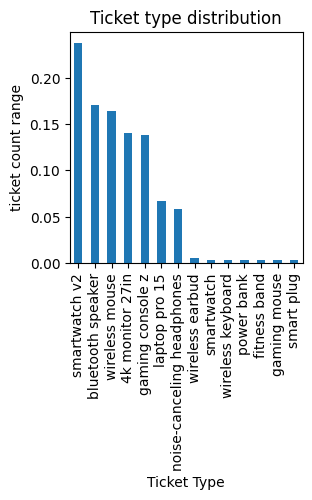

In [5]:
df["Product Purchased"].str.strip().str.lower().value_counts(normalize=True).plot(kind='bar',figsize=(3,3),xlabel="Ticket Type", ylabel="ticket count range",title="Ticket type distribution")

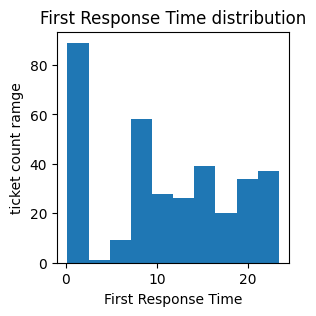

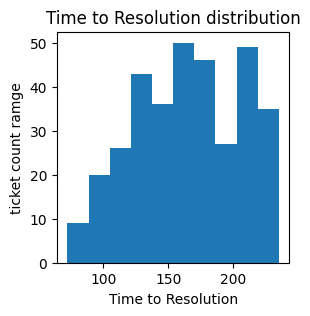

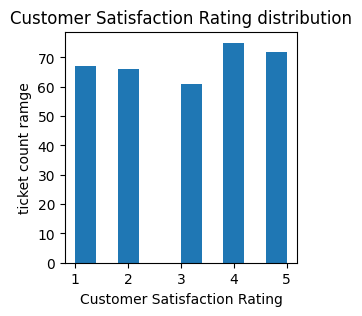

In [6]:
numerical_cols=['First Response Time','Time to Resolution','Customer Satisfaction Rating']
for col in numerical_cols:
    df[col].plot(kind='hist',figsize=(3,3),xlabel=col,ylabel="ticket count ramge",title=f"{col} distribution")
    plt.show()

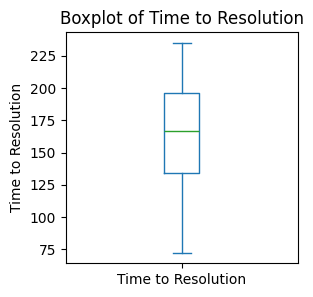

In [7]:
df["Time to Resolution"].plot(
    kind="box",
    figsize=(3,3)
)

plt.title("Boxplot of Time to Resolution")
plt.ylabel("Time to Resolution")
plt.show()

<Axes: >

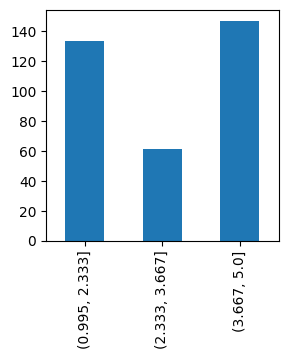

In [8]:
df['Customer Satisfaction Rating'].value_counts(bins=3).sort_index().plot(kind="bar",figsize=(3,3))

In [9]:
import sys
print(sys.executable)

d:\customer_support-ai\venv\Scripts\python.exe


In [10]:
from ydata_profiling import ProfileReport

C:\Users\keertika\AppData\Local\Temp\ipykernel_11896\44057814.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [11]:
profile = ProfileReport(df, title="Customer Support Tickets Profiling Report", explorative=True)

In [12]:
profile.to_file("../customer_support_eda_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 150.52it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

#multivariate EDA

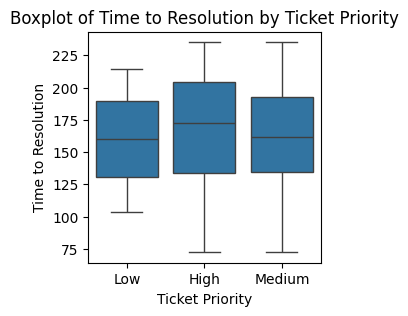

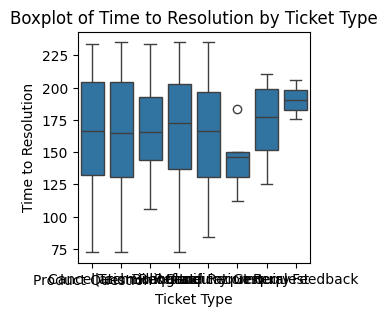

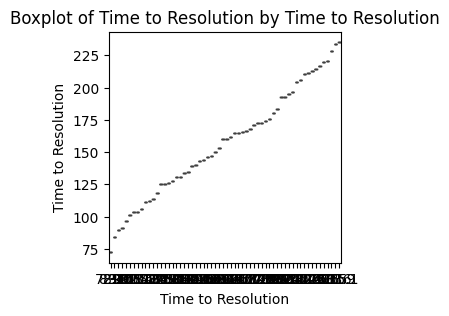

In [13]:
EDA_columns = ['Ticket Priority','Ticket Type', 'Time to Resolution']
for col in EDA_columns:
    plt.figure(figsize=(3,3))
    sns.boxplot(x=col, y='Time to Resolution', data=df)
    plt.title(f"Boxplot of Time to Resolution by {col}")
    plt.xlabel(col)
    plt.ylabel("Time to Resolution")
    plt.show()

In [14]:

EDA_columns = ['Customer Satisfaction Rating', 'Time to Resolution']
df[EDA_columns].corr()

,Customer Satisfaction Rating,Time to Resolution
Customer Satisfaction Rating,1.000000,-0.020115
Time to Resolution,-0.020115,1.000000


<Axes: xlabel='Ticket Type', ylabel='Time to Resolution'>

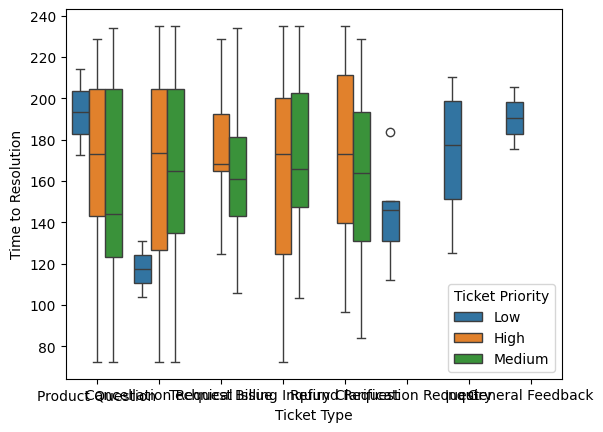

In [15]:
sns.boxplot(data=df,x='Ticket Type',y='Time to Resolution',hue='Ticket Priority')

    

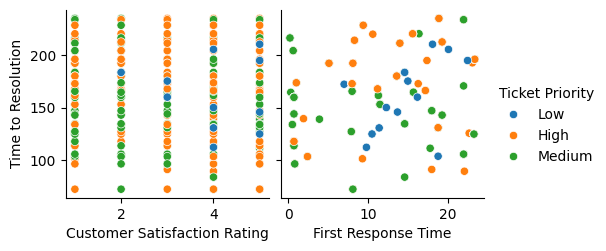

In [16]:
sns.pairplot(x_vars=['Customer Satisfaction Rating','First Response Time'], y_vars=['Time to Resolution'], hue='Ticket Priority', data=df)
# It is useful for getting an overall visual understanding of numerical relationships.

In [17]:
df['encoded_Priority'] = LabelEncoder().fit_transform(df['Ticket Priority'])
df_corr_col =['Time to Resolution', 'encoded_Priority']
df[df_corr_col].corr()

,Time to Resolution,encoded_Priority
Time to Resolution,1.000000,-0.068192
encoded_Priority,-0.068192,1.000000


<Axes: >

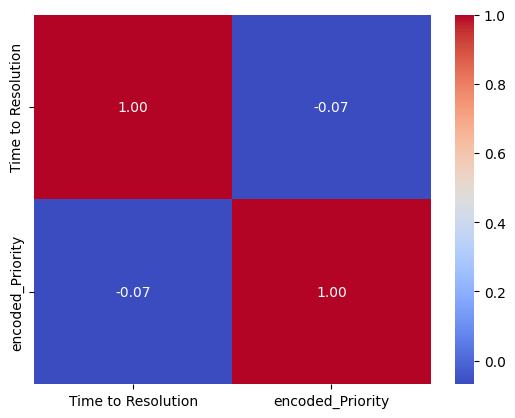

In [18]:
sns.heatmap(df[df_corr_col].corr(), annot=True, cmap='coolwarm', fmt=".2f")

<Axes: >

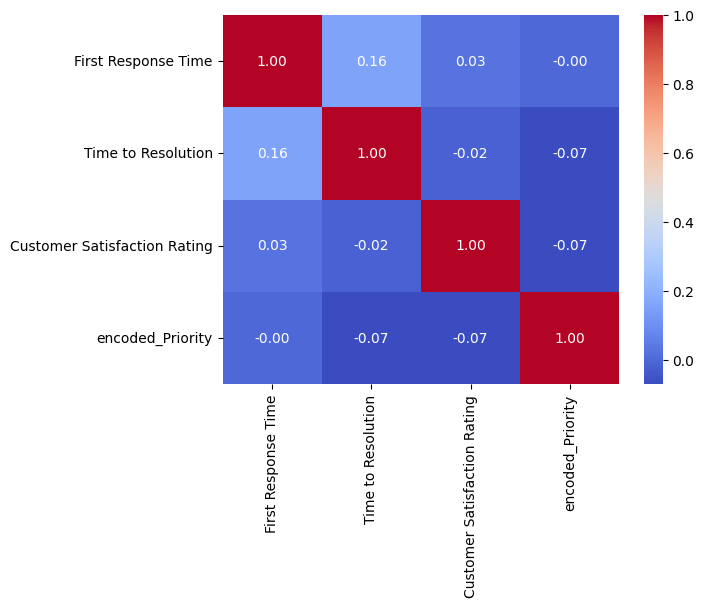

In [19]:
numerical_cols=df.select_dtypes(include=[np.number])
sns.heatmap(numerical_cols.corr(),annot=True, cmap='coolwarm', fmt=".2f")